# Six Seconds to Decide

End-to-end, leakage-safe reconstruction of the Solana sniper. This notebook is a clean orchestration layer over the tested repository modules; detailed outputs are cached outside Git.

## Decision clock

`t_decision` is the moment of deployment. Entry features are limited to the signed deployment message and deployer activity with `timestamp < deployment.blockTime`. Same-second history, transaction `meta`, target reactions, trades, candles, outcomes, and landed Jito data are excluded. Trades/Jito are introduced only in behavior and backtest sections.

In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json
import os
import sys
import warnings

import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
if (cwd / 'pyproject.toml').exists():
    ROOT = cwd
elif (cwd.parent / 'pyproject.toml').exists():
    ROOT = cwd.parent
else:
    raise RuntimeError(
        'Could not locate the repository root. Expected pyproject.toml '
        'in the current directory or its parent.'
    )
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
from solana_sniper_reverse_engineering.config import ensure_output_dirs
ensure_output_dirs()

def run_quietly(function, *args, **kwargs):
    # Successful runners are verbose; exceptions still propagate and fail the cell.
    runner_stdout = StringIO()
    with redirect_stdout(runner_stdout):
        return function(*args, **kwargs)

def display_image(filename):
    display(Image(filename=str(Path(filename))))

## 1. Reconstruct target behavior

In [2]:
from solana_sniper_reverse_engineering.behavior import run as run_behavior
behavior = run_quietly(run_behavior)
display(pd.DataFrame([
    ('core deployment tokens bought', behavior['scope']['core_bought_deployment_tokens']),
    ('wallet bought positions', behavior['scope']['wallet_bought_tokens']),
    ('entry USD mean', behavior['entry_usd_core']['mean']),
    ('entry USD median', behavior['entry_usd_core']['median']),
    ('entry USD standard deviation', behavior['entry_usd_core']['std']),
    ('same-slot share', behavior['zero_slot']['share']),
    ('same-slot median tx delta', behavior['same_slot_position']['median_tx_delta']),
    ('hold median seconds', behavior['hold_seconds']['median']),
    ('partial-exit share', behavior['exit_structure']['partial_exit_share']),
    ('sell transactions', behavior['exit_structure']['sell_transactions_for_bought_positions']),
    ('net cash flow USD', behavior['cashflow_performance_bought_positions']['net_pnl_usd']),
], columns=['metric','value']))

,metric,value
0,core deployment tokens bought,1.592700e+04
1,wallet bought positions,1.616300e+04
2,entry USD mean,2.637361e+02
3,entry USD median,1.841185e+02
4,entry USD standard deviation,2.331034e+02
5,same-slot share,7.963207e-01
6,same-slot median tx delta,1.180000e+02
7,hold median seconds,6.000000e+00
8,partial-exit share,9.659098e-01
9,sell transactions,7.080500e+04


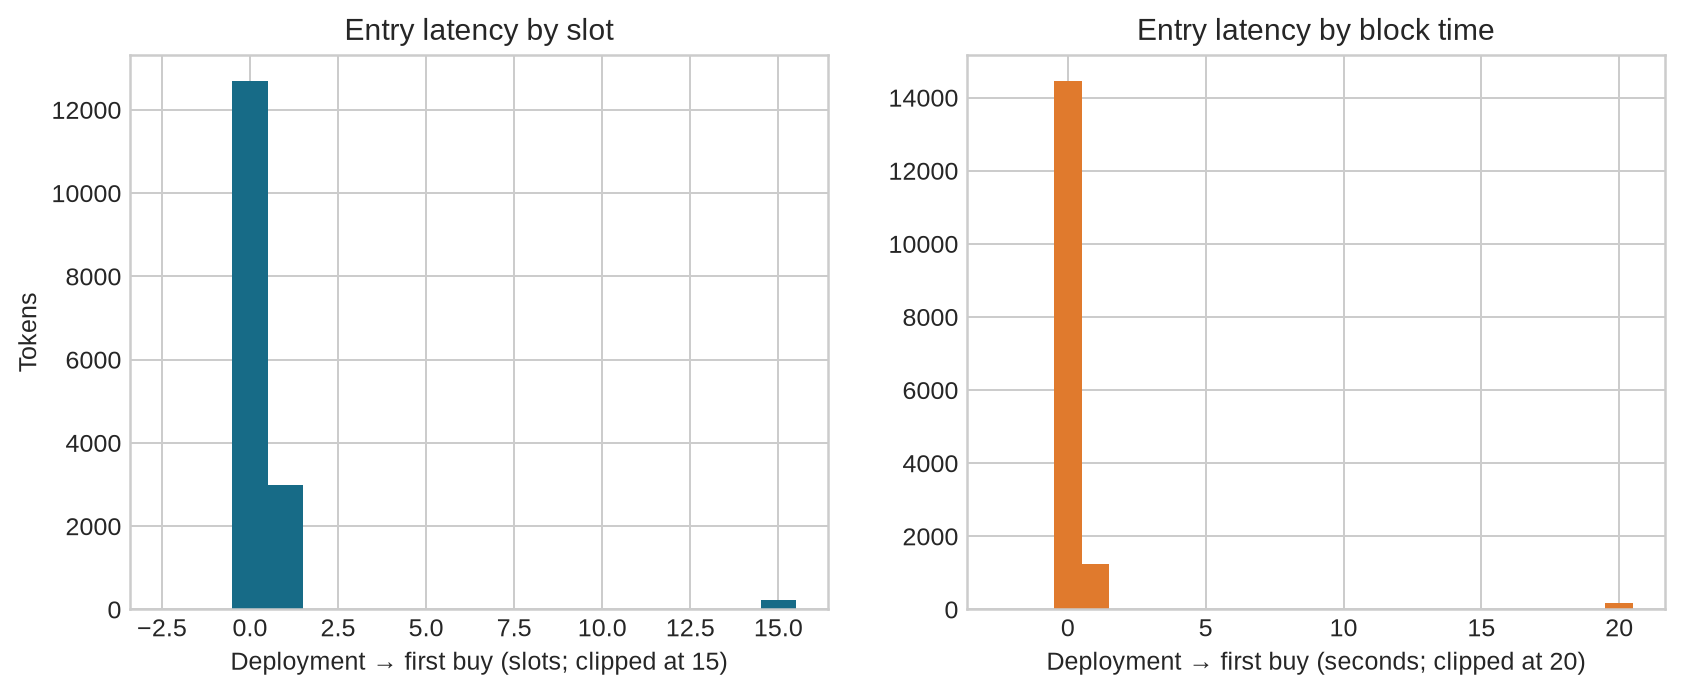

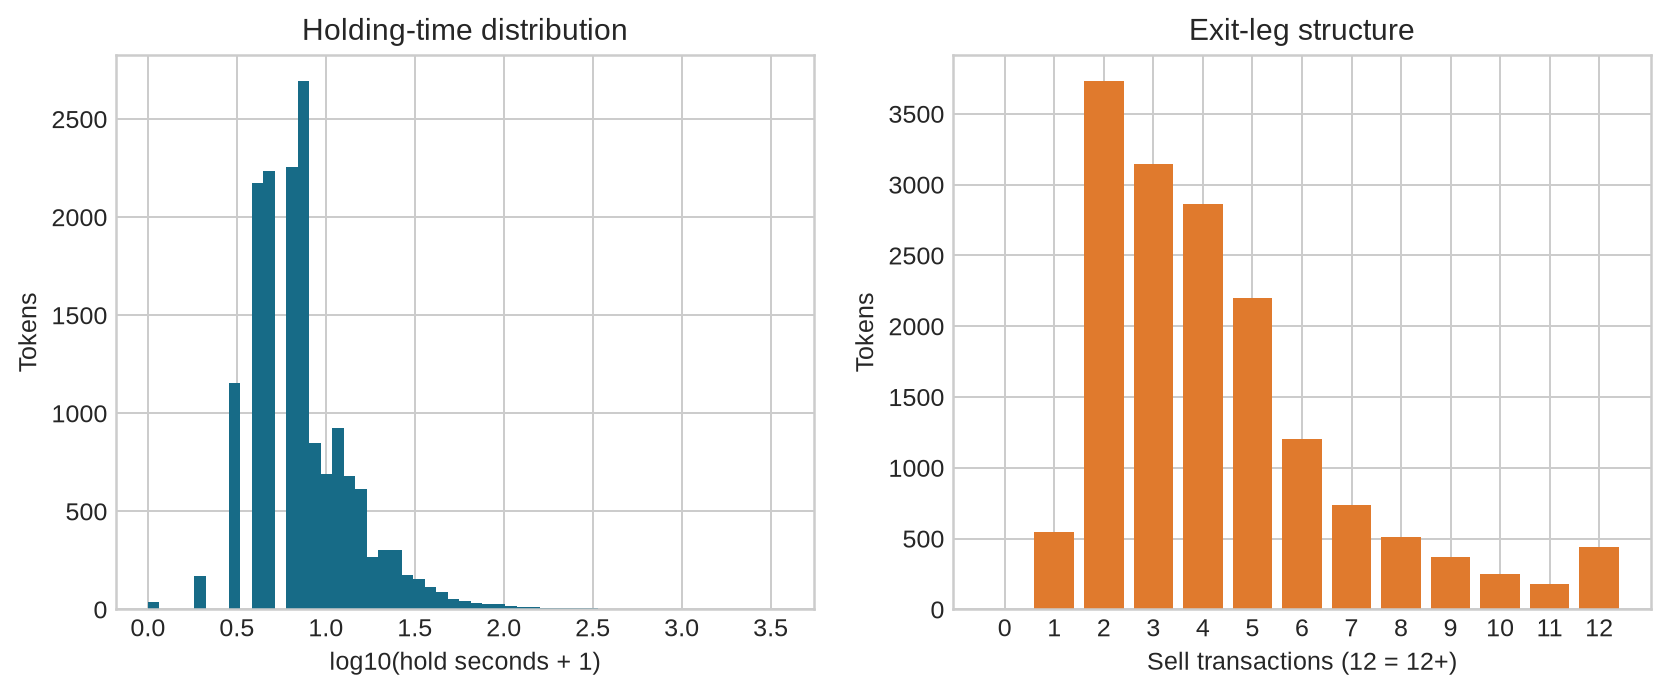

In [3]:
display_image('submission/figures/02_entry_latency.png')
display_image('submission/figures/03_holds_and_exits.png')

## 2. Build the legal feature store

On a fresh run the next cell streams both gzip archives once. It decodes signed message fields only; the 15 GiB negative archive is never expanded in place. Deterministic Parquet caches make reruns fast.

In [4]:
from solana_sniper_reverse_engineering.message_features import run as extract_messages
from solana_sniper_reverse_engineering.feature_store import run as build_features, audit
run_quietly(extract_messages)
feature_path = run_quietly(build_features)
feature_audit = run_quietly(audit, feature_path)
display(pd.Series(feature_audit, name='value').rename_axis('audit gate').to_frame())

,value
audit gate,
rows,5076421
tokens,5076421
duplicate_keys,0
positives,15927
missing_history,1442833
missing_message,6274
invalid_activity_recency,0
invalid_deploy_recency,0


In [5]:
feature_dictionary = pd.read_csv('submission/tables/feature_dictionary.csv')
display(feature_dictionary[['family','temporal_construction','legality']])

,family,temporal_construction,legality
0,deployment cadence,strict earlier deployment second,known before current deployment
1,timing,current deployment clock,at t_decision
2,metadata text,current signed message,message exists by t_decision
3,metadata reuse,grouped windows ending one second before,strictly earlier deployments
4,dev buy,current signed message,message exists by t_decision
5,message structure,current signed message,message exists by t_decision
6,compute budget,current signed message,message exists by t_decision
7,top-level transfers,current signed message,message exists by t_decision
8,historical activity,ASOF activity.timestamp < block_time,only strictly earlier rows
9,rolling activity,"[t-window,t) via strict ASOF states",only strictly earlier rows


## 3. Chronological model and interpretation

The target-active era (March 12–April) trains, May selects the family and fixed threshold, and June is a reporting test. An initial HGB run had already inspected June before LightGBM was introduced, so June is not described as literally untouched. Accuracy is intentionally omitted.

In [6]:
from solana_sniper_reverse_engineering.modeling import run as run_modeling
with warnings.catch_warnings():
    warnings.filterwarnings(
        'ignore', message="'n_jobs' has no effect.*", category=FutureWarning
    )
    classification = run_quietly(run_modeling, feature_path)
display(pd.DataFrame(classification['experiments_may']).T[
    ['pr_auc','precision','recall','f1']
])

,pr_auc,precision,recall,f1
prevalence_baseline,0.005699,0.000000,0.000000,0.000000
time_only_hgb,0.005589,0.005828,0.803624,0.011572
regularized_logistic,0.056056,0.097665,0.148316,0.117776
hgb_without_activity,0.072333,0.112837,0.211739,0.147220
constrained_hist_gradient_boosting,0.111303,0.189068,0.240496,0.211704
regularized_lightgbm,0.144513,0.218511,0.264132,0.239165


,rank,feature,importance_pr_auc_drop,direction
0,1,seconds_since_prior_deploy,0.036924,increasing
1,2,dev_buy_sol,0.028481,increasing
2,3,hist_quote_sol_sum,0.024655,increasing
3,4,hist_open_close_count,0.022865,increasing
4,5,hist_cost_usd_sum,0.020864,increasing
5,6,latest_prior_launch_dev_sell_latency_seconds,0.013189,decreasing
6,7,prior_deploy_count_1d,0.009537,decreasing
7,8,hist_burn_count,0.009010,increasing
8,9,hist_burn_count_30d,0.008153,increasing
9,10,hist_claim_fee_usd_per_claimed_launch,0.008011,non-monotonic/mixed


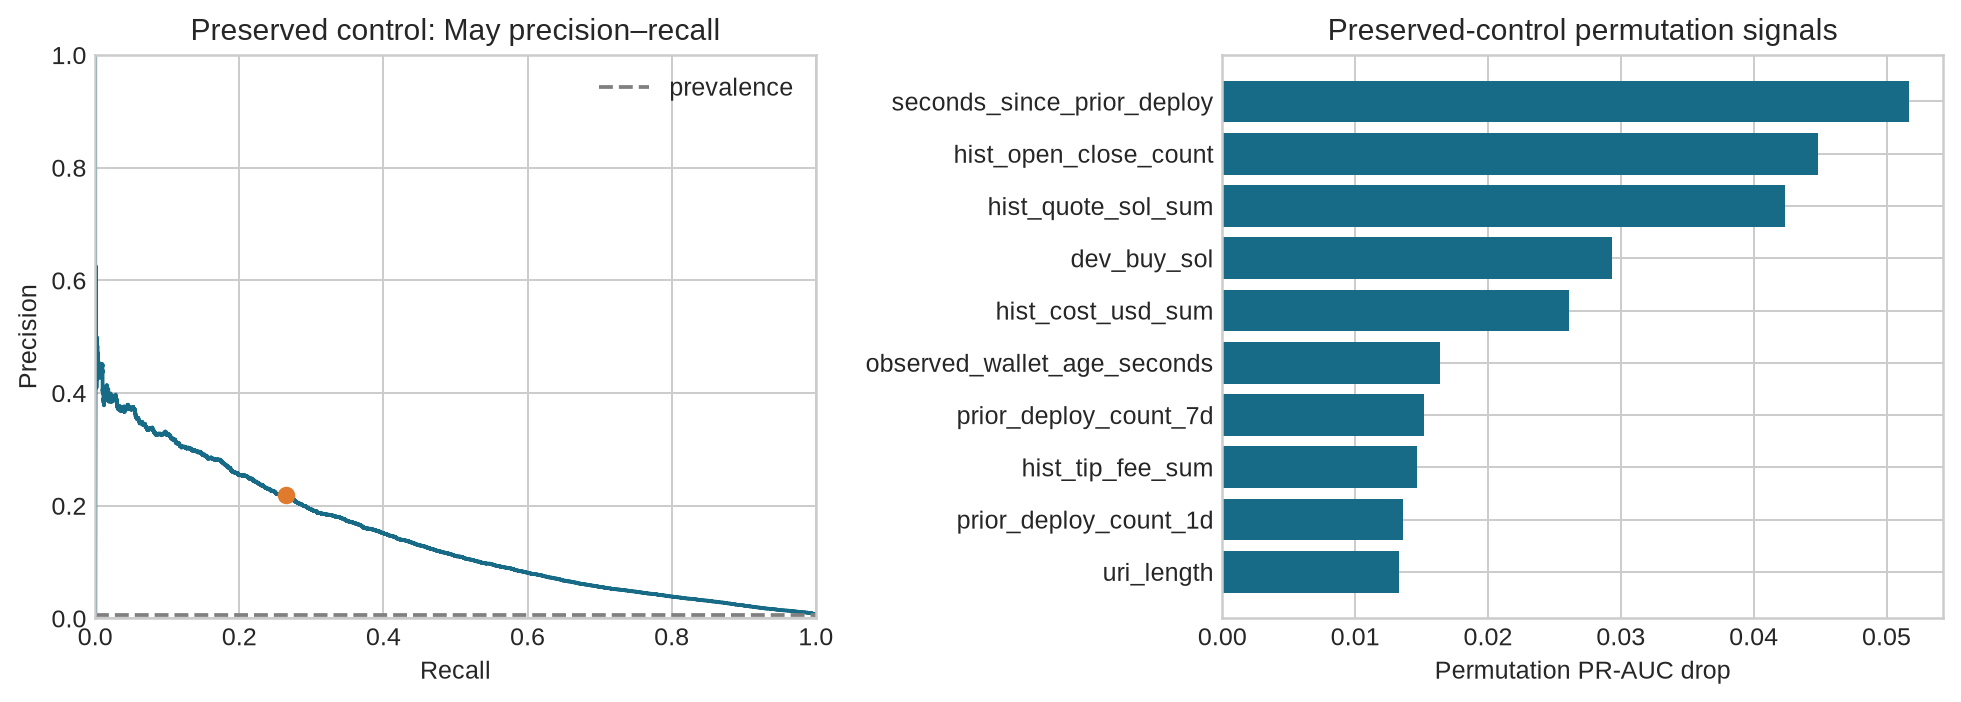

In [7]:
final_importance = pd.read_csv('submission/tables/final_selector_feature_importance.csv')
final_effects = pd.read_csv('submission/tables/final_selector_feature_effects.csv')
top10_notebook = final_importance.head(10)[['rank','feature','importance_pr_auc_drop']].merge(
    final_effects[['feature','direction']].drop_duplicates(), on='feature', how='left'
)
display(top10_notebook)
display_image('submission/figures/05_model_diagnostics.png')

## 4. Frozen replica, backtest, and head-to-head

In [8]:
from solana_sniper_reverse_engineering.backtest import run as run_backtest
backtest = run_quietly(run_backtest, force=True)
display(backtest['selection_overlap'])
display(pd.DataFrame(backtest['primary_fee_results']).T)

{'replica_entries': 3904,
 'target_entries': 4195,
 'overlap': 564,
 'precision_vs_target': 0.1444672131147541,
 'recall_of_target': 0.13444576877234804}

,replica,target_equal_stake
delay_0,"{'selected_tokens': 3904, 'filled_trades': 389...","{'selected_tokens': 4195, 'filled_trades': 419..."
delay_1,"{'selected_tokens': 3904, 'filled_trades': 389...","{'selected_tokens': 4195, 'filled_trades': 419..."
delay_2,"{'selected_tokens': 3904, 'filled_trades': 389...","{'selected_tokens': 4195, 'filled_trades': 419..."


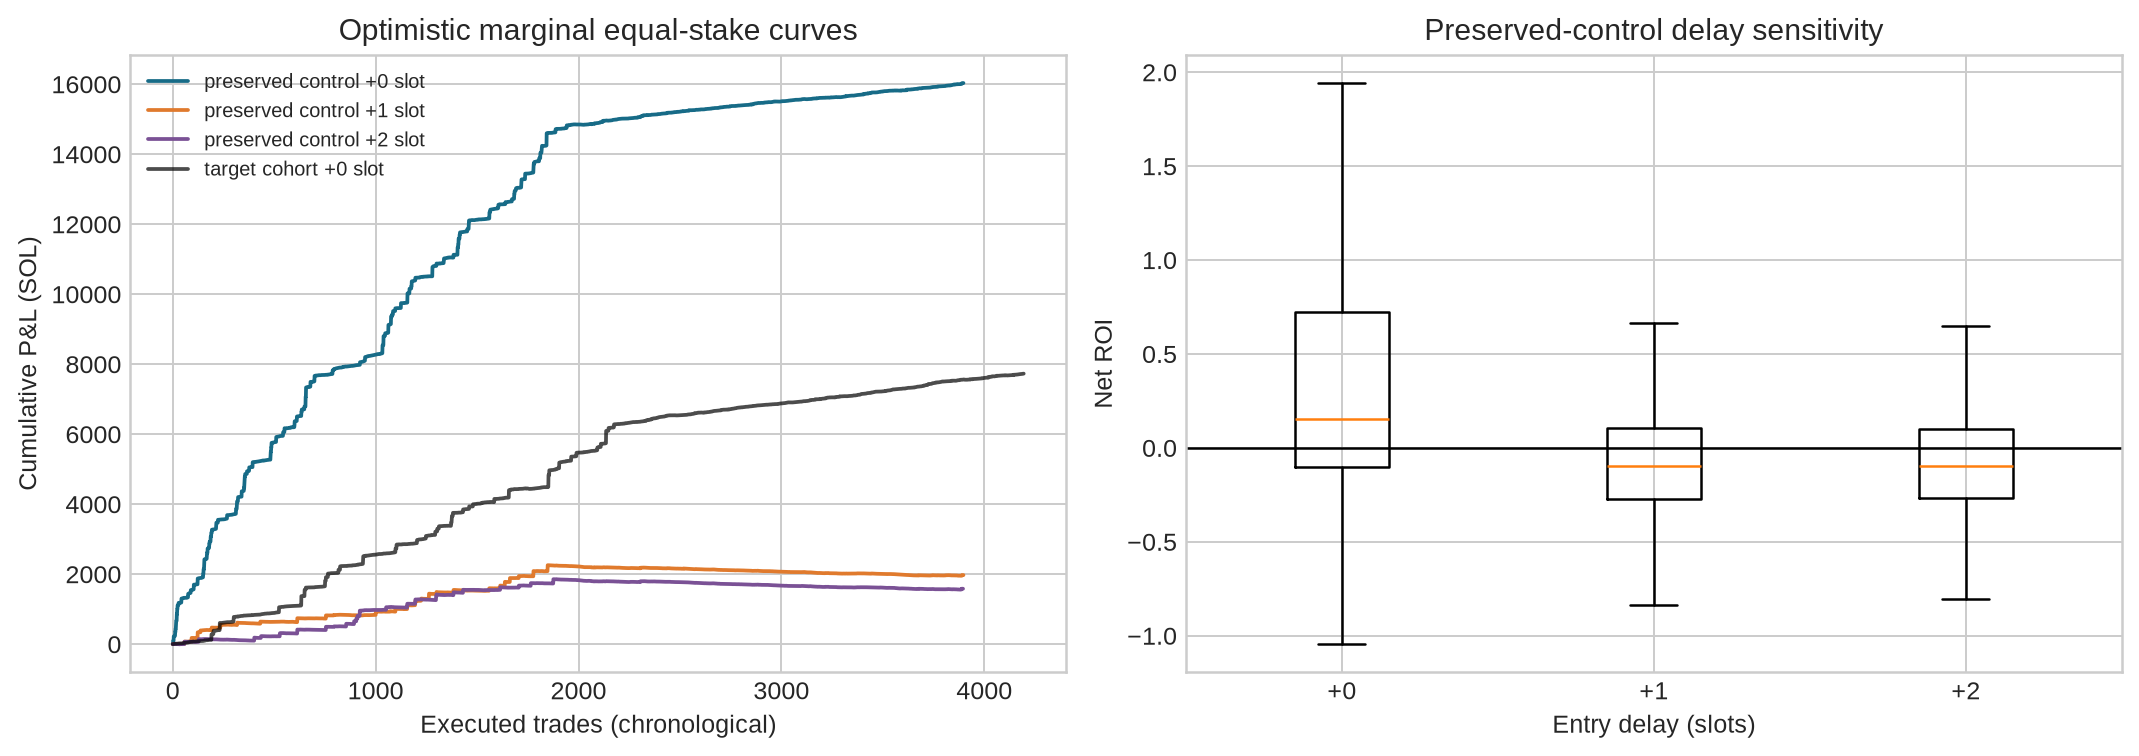

In [9]:
display_image('submission/figures/06_backtest_comparison.png')

## 5. Falsification

The robustness run retrains on a through-March window, validates April, tests top-feature stability, missing-history/dev-buy subgroups, concentration, calibration, and threshold sensitivity. Fee, 0/1/2-slot delay, slippage, tail-cap, and no-fill stresses are part of the backtest.

In [10]:
from solana_sniper_reverse_engineering.robustness import run as run_robustness
robustness = run_quietly(run_robustness)
display(robustness['alternate_temporal_validation'])
display(robustness['top10_stability'])

{'train': '2026-03-12 through 2026-03-31, all positives + deterministic 1/2 negatives',
 'validation': '2026-04-01 through 2026-04-30, full population',
 'metrics': {'rows': 803491,
  'positives': 3410,
  'prevalence': 0.004243980330831335,
  'pr_auc': 0.09632851157375566,
  'pr_auc_lift_over_prevalence': 22.697680965662318,
  'roc_auc': 0.9088863704162857,
  'threshold': 0.06568684806611273,
  'precision': 0.14534974295061537,
  'precision_lift_over_prevalence': 34.248448772179735,
  'recall': 0.27360703812316717,
  'f1': 0.18984637297792248,
  'predicted_entries': 6419,
  'predicted_entry_rate': 0.007988888487861097,
  'true_positives': 933}}

{'april_top10': ['dev_buy_sol',
  'seconds_since_prior_deploy',
  'prior_deploy_count_1d',
  'hist_open_close_count',
  'hist_cost_usd_sum',
  'hist_quote_sol_sum',
  'hist_burn_count',
  'hist_tip_fee_sum',
  'prior_deploy_count_7d',
  'hist_sell_count'],
 'may_top10': ['seconds_since_prior_deploy',
  'hist_open_close_count',
  'hist_quote_sol_sum',
  'dev_buy_sol',
  'hist_cost_usd_sum',
  'observed_wallet_age_seconds',
  'prior_deploy_count_7d',
  'hist_tip_fee_sum',
  'prior_deploy_count_1d',
  'uri_length'],
 'intersection': ['dev_buy_sol',
  'hist_cost_usd_sum',
  'hist_open_close_count',
  'hist_quote_sol_sum',
  'hist_tip_fee_sum',
  'prior_deploy_count_1d',
  'prior_deploy_count_7d',
  'seconds_since_prior_deploy'],
 'intersection_count': 8,
 'jaccard': 0.6666666666666666}

## 6. Targeted methodological audit

This controlled pass compares January–April with March 12–April training, quantifies redundancy among the top activity signals, and simulates +1 through +250 landed transaction-position offsets plus a pre-June empirical same-slot policy. Trade ordering remains backtest-only.

In [11]:
from solana_sniper_reverse_engineering.methodological_audit import run as run_audit
audit_results = run_quietly(run_audit, feature_path)
display({
    'active-period decision': audit_results['active_period_training']['decision'],
    'May activity-signal median Spearman': audit_results['signal_redundancy']['all_may_pairwise_spearman'],
})

{'active-period decision': 'Adopt active-era training: it improves May PR-AUC, precision, and F1 under the declared selection protocol; June PR-AUC and precision also improve, while June recall and F1 are slightly lower.',
 'May activity-signal median Spearman': {'min': 0.7782522272084953,
  'median': 0.9407173091725483,
  'max': 0.9989109691081987}}

## 7. Third-pass research

The control is preserved. New families are selected only from April/May chronological evidence. Creator-fee claims and a deployer's own sells of prior launches are timestamped outcome proxies—not token ROI—and enter only after observation. The reproducible runner is `.venv/bin/python scripts/run_third_pass.py all`; the cells below present its tracked small outputs.

In [12]:
historical = json.loads(Path('submission/tables/historical_outcome_audit.json').read_text())
developer_sell = json.loads(Path('submission/tables/developer_sell_outcome_results.json').read_text())
ranking = json.loads(Path('submission/tables/ranking_hard_negative_results.json').read_text())
strategy = json.loads(Path('submission/tables/profitable_disagreement_results.json').read_text())
display(pd.DataFrame({
    period: {
        'control_pr_auc': result['baseline']['pr_auc'],
        'creator_fee_pr_auc': result['creator_fee_quality']['pr_auc'],
        'all_outcomes_pr_auc': result['creator_fee_plus_developer_sell']['pr_auc'],
        'all_minus_control': result['creator_fee_plus_developer_sell']['pr_auc'] - result['baseline']['pr_auc'],
    } for period, result in developer_sell['windows'].items()
}).T)

,control_pr_auc,creator_fee_pr_auc,all_outcomes_pr_auc,all_minus_control
april,0.097049,0.107299,0.107562,0.010513
may,0.144649,0.147959,0.153367,0.008718


In [13]:
final_classification = pd.DataFrame({
    'May selection': developer_sell['windows']['may']['creator_fee_plus_developer_sell'],
    'June reporting': developer_sell['june_reporting_only']['creator_fee_plus_developer_sell'],
}).T
display(final_classification[
    ['prevalence','pr_auc','pr_auc_lift_over_prevalence',
     'precision','precision_lift_over_prevalence','recall','f1','predicted_entries']
])

,prevalence,pr_auc,pr_auc_lift_over_prevalence,precision,precision_lift_over_prevalence,recall,f1,predicted_entries
May selection,0.005699,0.153367,26.910851,0.216387,37.968754,0.297026,0.250374,6969
June reporting,0.004923,0.065416,13.28729,0.127565,25.910772,0.136353,0.131812,4484


In [14]:
display(ranking['pre_june_decisions'])
display(strategy['pre_june_decision'])
display(strategy['pre_june_strategy_operating_point'])

{'hard_negative': {'april_pr_auc_delta': 0.0008769026845452804,
  'may_pr_auc_delta': -0.01330897385979335,
  'status': 'DROP'},
 'missing_history_mixture': {'april_pr_auc_delta': -0.0021594011852764106,
  'may_pr_auc_delta': -0.0010373014352616228,
  'status': 'DROP'},
 'time_bucket_lambdarank': {'april_pr_auc_delta': -0.006752905871802023,
  'may_pr_auc_delta': -0.04096337462808891,
  'status': 'DROP'}}

{'april_claim_hit_rate_gain': 0.016516228154407536,
 'may_claim_hit_rate_gain': 0.008358921869669057,
 'rule': 'KEEP only if equal-count two-stage selection improves the seven-day creator-fee hit rate in both April and May.',
 'status': 'KEEP'}

{'april_two_stage_claim_hit_rate': 0.13440860215053763,
 'may_two_stage_claim_hit_rate': 0.13983628922237382,
 'selection_basis': 'Smallest tested pre-June operating point; creator-fee hit rate exceeds Model A in both April and May.',
 'status': 'KEEP',
 'trade_count_multiplier': 0.25}

## 8. Marginal +118 head-to-head

This table is the common equal-stake **marginal-price diagnostic**, not exact curve replay. Immediate execution is optimistic; +118 is landed transaction ordering rather than wall-clock latency or mempool visibility. Because increasing offsets change the fill population, conditional ROI need not move monotonically.

In [15]:
head_to_head = pd.read_csv('submission/tables/third_pass_head_to_head.csv')
display(head_to_head[[
    'policy','june_entries','target_overlap','precision_vs_target',
    'recall_of_target','marginal_offset118_fill_rate',
    'marginal_offset118_hit_rate','marginal_offset118_median_roi',
    'marginal_offset118_p99_capped_pnl_sol',
    'marginal_offset118_max_drawdown_sol',
]])

,policy,june_entries,target_overlap,precision_vs_target,recall_of_target,marginal_offset118_fill_rate,marginal_offset118_hit_rate,marginal_offset118_median_roi,marginal_offset118_p99_capped_pnl_sol,marginal_offset118_max_drawdown_sol
0,target_equal_stake_counterfactual,4195,NaN,NaN,NaN,0.733015,0.400650,-0.077688,108.836467,58.119072
1,baseline,3904,564.0,0.144467,0.134446,0.627561,0.432245,-0.048845,172.769172,28.400785
2,quality_augmented,4484,572.0,0.127565,0.136353,0.590098,0.431595,-0.052426,227.333755,33.384255
3,two_stage,4484,635.0,0.141615,0.151371,0.611285,0.439256,-0.046005,288.872304,30.994594
4,selective_two_stage,1121,177.0,0.157895,0.042193,0.644068,0.486150,-0.020559,215.764143,11.405647


## 9. Exact Pump curve execution bounds

The tested integer Pump replay inserts our buy and sell, price impact, fees, and intervening events into supported standard curves. The existing runner is invoked below and checked against its tracked JSON result. Fixed-quote and fixed-token continuation bound the missing downstream instruction intent. Nonstandard curves, migrations, counterfactual completions, and possible slippage-limit failures are excluded, not guessed.

In [16]:
from solana_sniper_reverse_engineering.curve_replay import run_curve_replay

curve_replay = run_quietly(run_curve_replay, force=False)
tracked_curve_replay = json.loads(
    Path('submission/tables/curve_replay_results.json').read_text()
)
assert curve_replay == tracked_curve_replay, 'Curve replay differs from tracked output'
curve_coverage_status = pd.read_csv(
    'submission/tables/curve_replay_coverage.csv'
)
assert not curve_coverage_status.empty

policy_labels = {
    'target_equal_stake': 'Target equal-stake diagnostic',
    'baseline_replica': 'Preserved control',
    'quality_augmented_replica': 'Final imitation',
    'two_stage': 'Equal-count two-stage',
    'selective_two_stage': 'Selective two-stage',
}
exact_rows = []
for policy, label in policy_labels.items():
    for intent in ('fixed_quote', 'fixed_token'):
        for fee_key, fee_label in (('fee_0.0095', '0.95%'), ('fee_0.0125', '1.25%')):
            metrics = curve_replay['results']['offset_118'][policy][intent][fee_key]
            exact_rows.append({
                'policy': label,
                'landed offset': '+118',
                'intent bound': intent.replace('_', '-'),
                'swap fee': fee_label,
                'selected': metrics['selected_tokens'],
                'supported': metrics['supported_tokens'],
                'supported coverage': metrics['coverage'],
                'median net ROI': metrics['median_net_roi'],
                'p99-capped P&L (SOL)': metrics['p99_capped_total_pnl_sol_supported'],
            })
exact_curve_table = pd.DataFrame(exact_rows)
exact_curve_display = exact_curve_table.copy()
exact_curve_display['supported coverage'] = exact_curve_display['supported coverage'].map('{:.2%}'.format)
exact_curve_display['median net ROI'] = exact_curve_display['median net ROI'].map('{:.2%}'.format)
exact_curve_display['p99-capped P&L (SOL)'] = exact_curve_display['p99-capped P&L (SOL)'].map('{:+.1f}'.format)
display(exact_curve_display)

,policy,landed offset,intent bound,swap fee,selected,supported,supported coverage,median net ROI,p99-capped P&L (SOL)
0,Target equal-stake diagnostic,+118,fixed-quote,0.95%,4195,2200,52.44%,-12.75%,-188.0
1,Target equal-stake diagnostic,+118,fixed-quote,1.25%,4195,2200,52.44%,-13.33%,-214.3
2,Target equal-stake diagnostic,+118,fixed-token,0.95%,4195,2282,54.40%,-10.34%,-18.1
3,Target equal-stake diagnostic,+118,fixed-token,1.25%,4195,2282,54.40%,-10.93%,-46.0
4,Preserved control,+118,fixed-quote,0.95%,3904,1831,46.90%,-9.44%,-117.5
5,Preserved control,+118,fixed-quote,1.25%,3904,1831,46.90%,-10.04%,-139.6
6,Preserved control,+118,fixed-token,0.95%,3904,1902,48.72%,-7.54%,+9.7
7,Preserved control,+118,fixed-token,1.25%,3904,1902,48.72%,-8.14%,-13.6
8,Final imitation,+118,fixed-quote,0.95%,4484,2241,49.98%,-9.85%,-175.3
9,Final imitation,+118,fixed-quote,1.25%,4484,2241,49.98%,-10.44%,-202.2


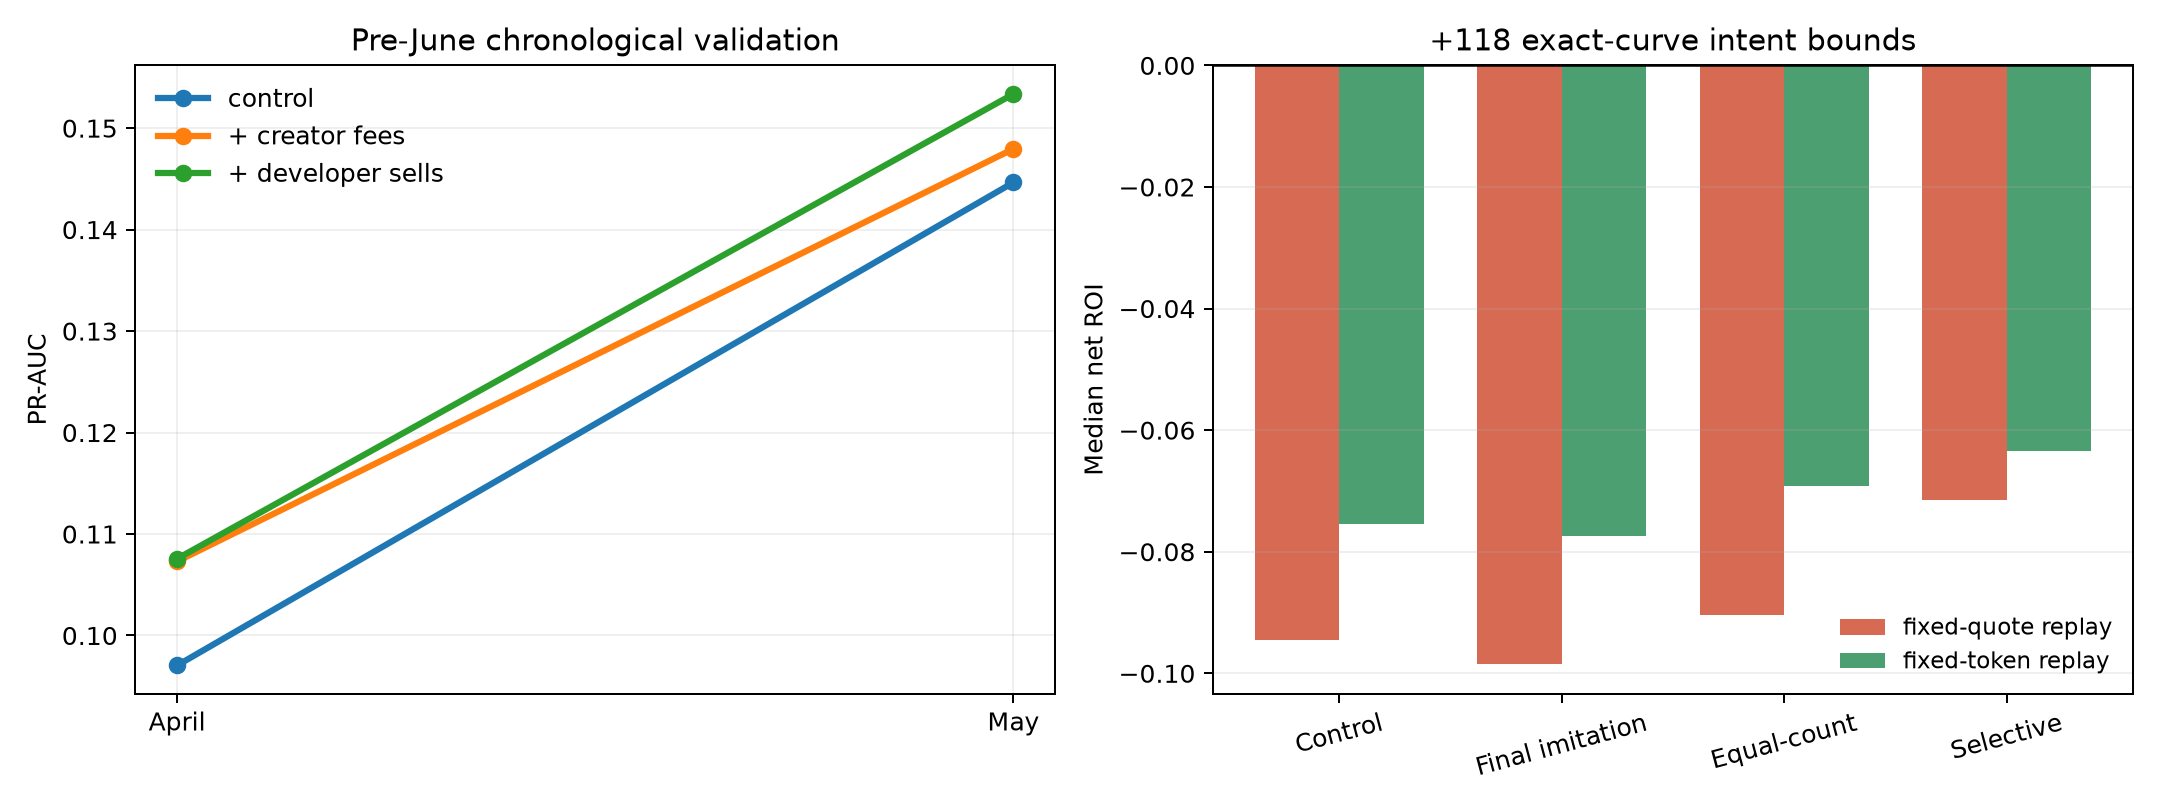

In [17]:
display_image('submission/figures/07_third_pass_summary.png')

## Conclusion

The strongest stable policy signals are deploy spacing, a meaningful dev buy, a latent wallet-scale/sophistication factor, avoidance of industrial deployment cadence, and observed quality of prior launches. Creator-fee and developer-sell history improve both pre-June windows; LambdaRank, hard-negative weighting, metadata expansion, and a missing-history mixture fail. A separately labeled economic ranker raises seven-day creator-fee hit rate in both validation months. Exact-curve +118 results remain negative at the median; the selective strategy has positive capped P&L under both observed buy-intent bounds. See `submission/writeup.md` for bounded claims and limitations.